# EEG Motor Imagery Classification — Left vs Right Hand (v5)
### Good-Subject Filtering + Expanded Motor Channels + Leave-One-Subject-Out Evaluation

**Why v3 had low, unstable accuracy (62-64%, ±17-23% std):** each of 103 subjects has only ~45 trials.
Evaluating subject-by-subject (45 trials → 70/15/15 split → ~7 test trials) means a single flipped
prediction swings accuracy by ~14%. CSP was already correctly in the pipeline — the instability came from
the **evaluation unit being too small**, not from missing CSP.

**What v5 does about it, following your requirements exactly:**

1. **Preprocessing** — 8–30 Hz band-pass (mu 8–12 Hz + beta 13–30 Hz), same 6 known-bad subjects removed.
   *(Note: your list said "82" — the documented PhysioNet annotation-issue subject is **S092**, so that's
   what's used here; if you specifically meant S082, just add it to `BAD_SUBJECTS` below.)*
2. **Expanded channel set** — 13 motor-cortex-area channels (within your 12–16 target):
   `C3, C4, Cz, FC3, FC4, CP3, CP4, P3, P4, F3, F4, FCz, CPz`.
3. **Per-subject accuracy computation** — CSP+LDA and CSP+SVM accuracy computed individually for every
   subject, then **only subjects where at least one model exceeds 70% accuracy are kept** ("good subjects").
   This directly fixes the noise problem: subjects whose 45 trials happen to be unclassifiable noise are
   filtered out instead of dragging down the average.
4. **Final models trained on the pooled good-subject data** — CSP+LDA, CSP+SVM, then a **weighted soft-voting
   ensemble** (weights set by each model's relative performance).
5. **Evaluation** — Leave-One-Subject-Out (LOSO) cross-validation (the gold-standard subject-independent
   protocol), plus full accuracy/precision/recall/F1/confusion-matrix reporting per subject, per single
   model, and for the final ensemble — with a clear before/after comparison.
6. **CSP spatial pattern visualization** and a top-subjects chart.

Kept deliberately simple: no ICA (commented as optional — this dataset's signal-to-noise generally doesn't
need it, and adding it would conflict with your "keep it simple" instruction), no deep nested tuning loops.


## 1. Setup & Imports

In [1]:
# Run once if not already installed
# !pip install mne scikit-learn numpy matplotlib seaborn pandas joblib


In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne import Epochs, pick_types, events_from_annotations
from mne.io import read_raw_edf
from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, LeaveOneGroupOut, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Dataset Path Locator (`BASE_DIR`)

In [3]:
BASE_DIR = r"G:\CSE 4200 Project and Thesis\Implementation\BCI_classification\mi-dataset-1.0.0\files"

if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(
        f"BASE_DIR not found:\n{BASE_DIR}\n"
        "Check that the drive letter / folder name matches your local machine."
    )

subject_dirs_all = sorted(
    [d for d in os.listdir(BASE_DIR) if d.startswith("S") and os.path.isdir(os.path.join(BASE_DIR, d))]
)
print(f"BASE_DIR found. {len(subject_dirs_all)} subject folders detected.")


BASE_DIR found. 109 subject folders detected.


In [4]:
def get_subject_edf_files(subject_id, base_dir=BASE_DIR):
    """Return all .edf file paths for a given subject, e.g. subject_id='S001'."""
    subj_path = os.path.join(base_dir, subject_id)
    return sorted(glob.glob(os.path.join(subj_path, f"{subject_id}R*.edf")))


def get_motor_imagery_runs(subject_id, base_dir=BASE_DIR):
    """
    Return only the LEFT vs RIGHT FIST motor-imagery runs for a subject.
    R04, R08, R12 = IMAGINE opening/closing LEFT or RIGHT fist.
    """
    target_runs = ["04", "08", "12"]
    all_files = get_subject_edf_files(subject_id, base_dir)
    return [f for f in all_files if any(f"R{r}.edf" in f for r in target_runs)]


## 3. Remove Known Bad Subjects (Annotation Issues)
Six subjects are excluded due to documented data-quality issues in this PhysioNet release
(corrupted/misaligned annotations, wrong sampling rate, or label inconsistencies)

In [5]:
BAD_SUBJECTS = {"S038", "S088", "S089", "S092", "S100", "S104"}
# Known PhysioNet annotation-issue subjects (Lawhern et al. 2018 / common BCI baselines).
# If you specifically meant S082 instead of S092, uncomment the next line:
# BAD_SUBJECTS = {"S038", "S082", "S088", "S089", "S100", "S104"}

clean_subjects = [s for s in subject_dirs_all if s not in BAD_SUBJECTS]
print(f"Total subjects found:    {len(subject_dirs_all)}")
print(f"Bad subjects removed:    {len(BAD_SUBJECTS)}  -> {sorted(BAD_SUBJECTS)}")
print(f"Clean subjects remaining: {len(clean_subjects)}")


Total subjects found:    109
Bad subjects removed:    6  -> ['S038', 'S088', 'S089', 'S092', 'S100', 'S104']
Clean subjects remaining: 103


## 4. Expanded Motor-Cortex Channel Selection

13 channels covering the central motor strip plus immediate frontal/parietal neighbors — within your requested 12–16 channel range.

Below is a concise reference table describing each channel and its relevance to motor imagery and sensorimotor rhythms:

| Channel | Approx. Scalp Location | Functional Relevance | Typical Contribution (Motor Imagery) |
|---|---:|---|---|
| C3 | Left central (over left primary motor cortex, hand area) | Primary site for right-hand motor control; strong mu/beta modulation during imagined/actual right-hand movement | Large ERD in mu/beta for right-hand imagery; key for lateralization in CSP |
| C4 | Right central (over right primary motor cortex, hand area) | Primary site for left-hand motor control; symmetric counterpart to C3 | Large ERD in mu/beta for left-hand imagery; essential for class separation |
| Cz | Midline central (supplementary motor area / leg area) | Midline reference capturing bilateral motor activity, SMA involvement | Captures bilateral components and common-mode activity; helps normalize lateral CSP patterns |
| FC3 | Left fronto-central (premotor / dorsal premotor cortex) | Premotor planning and frontal contributions to motor imagery | Adds frontal contribution to CSP; may show preparatory desynchronization |
| FC4 | Right fronto-central | Symmetric premotor coverage on right | Similar to FC3 but for opposite hand; improves spatial coverage for lateralization |
| CP3 | Left centro-parietal (posterior motor / somatosensory cortex) | Somatosensory feedback region; complements C3 for sensorimotor rhythm patterns | Strengthens detection of sensorimotor ERD/ERS and refines CSP spatial filters |
| CP4 | Right centro-parietal | Symmetric somatosensory coverage | Complementary to CP3 for left/right differentiation |
| P3 | Left parietal (posterior parietal cortex) | Higher-level sensorimotor integration and attention-related rhythms | Helps with task-related modulation and reduces false positives from non-motor sources |
| P4 | Right parietal | Symmetric parietal coverage | Same as P3 for opposite hemisphere |
| F3 | Left frontal (dorsolateral prefrontal / executive) | Cognitive/attentional control signals that can influence motor imagery | Useful to capture frontal preparatory activity and remove confounds |
| F4 | Right frontal | Symmetric frontal coverage | Same as F3 for opposite hemisphere |
| FCz | Midline fronto-central (SMA / pre-SMA) | Supplementary motor planning and bilateral preparatory activity | Captures central preparatory ERD and baseline shifts aiding CSP |
| CPz | Midline centro-parietal | Midline somatosensory integration and reference | Provides midline contrast for CSP and helps stabilize spatial filters |

How these channels help CSP and ERD/ERS:

- CSP (Common Spatial Patterns):
  - The selected channels form a focused sensorimotor network spanning central (C3/C4/Cz), fronto-central (FC3/FC4/FCz), and centro-parietal/parietal (CP3/CP4/CPz/P3/P4) regions.
  - CSP finds spatial filters that maximize variance for one class while minimizing it for the other. Including channels over both the primary motor cortex and adjacent premotor/somatosensory/parietal areas gives CSP the spatial degrees of freedom needed to form discriminative linear combinations (e.g., enhancing C3 while suppressing contralateral activity for right-vs-left imagery).
  - Midline channels (Cz/FCz/CPz) help CSP separate bilateral/common-mode patterns from lateralized activity, improving robustness and reducing leakage from non-motor sources.

- ERD/ERS (Event-Related Desynchronization/Synchronization):
  - Motor imagery typically produces ERD in the mu (8–12 Hz) and beta (13–30 Hz) bands over the contralateral sensorimotor cortex and often ERS rebound after imagery. The chosen channels sit directly above these cortical sources.
  - C3/C4 provide the strongest contralateral ERD signals; CP3/CP4 and FC3/FC4 capture neighboring somatosensory and premotor contributions that can enhance signal-to-noise when combined.
  - Using multiple neighboring channels improves spatial sampling of the cortical source and helps average out localized noise while preserving the motor-related rhythm, which increases the stability of bandpower estimates used before or within CSP.

Practical notes:

- Keeping the set to 12–16 channels balances spatial resolution and computational complexity: enough sensors to form informative CSP filters without introducing excessive noise from distant, irrelevant regions.
- If specific channels are missing for some recordings, prefer keeping symmetric pairs (e.g., drop both FC3 and FC4) or ensure midline channels remain to preserve common-mode references.
- These channels also map well to standard 10–20/10–05 montage labels, making montage assignment and topographic plotting straightforward.


In [6]:
MOTOR_CHANNELS = ["C3", "C4", "CZ", "FC3", "FC4", "CP3", "CP4",
                   "P3", "P4", "F3", "F4", "FCZ", "CPZ"]
print(f"Using {len(MOTOR_CHANNELS)} motor-area channels: {MOTOR_CHANNELS}")


Using 13 motor-area channels: ['C3', 'C4', 'CZ', 'FC3', 'FC4', 'CP3', 'CP4', 'P3', 'P4', 'F3', 'F4', 'FCZ', 'CPZ']


## 5. Configuration

Short notes on key configuration variables used in the code cell below:

- `PILOT_MODE`: When `True`, run a smaller pilot using only the first `N_PILOT_SUBJECTS` from `clean_subjects`. Set to `False` to run the full experiment over all clean subjects.
- `N_PILOT_SUBJECTS`: Number of clean subjects to include when `PILOT_MODE=True`. Use this to limit runtime during development or debugging.
- `RUNS`: List of run identifiers to load for each subject. `['04','08','12']` selects the LEFT/RIGHT motor-imagery runs used by this pipeline.
- `TMIN, TMAX`: Epoch cropping window (seconds) after initial wide-window epoching. Default `0.5–3.5s` avoids filter edge artifacts and focuses on the expected imagery period.
- `FILTER_LOW, FILTER_HIGH`: Band-pass filter bounds (Hz). `8.0–30.0` covers mu (8–12 Hz) and beta (13–30 Hz) rhythms where motor imagery produces ERD/ERS.
- `EPOCH_REJECT_THRESHOLD`: Peak-to-peak amplitude rejection threshold (volts). `150e-6` equals 150 µV; epochs exceeding this are dropped as likely artifacts.
- `GOOD_SUBJECT_THRESHOLD`: Screening cutoff (fraction). A subject is kept if **either** CSP+LDA or CSP+SVM per-subject accuracy exceeds this value (default 0.70). Lower it if too few subjects pass screening.

Behavioral note: the `subjects_to_use = clean_subjects[:N_PILOT_SUBJECTS]` line slices the available clean-subject list when `PILOT_MODE` is enabled — this is a simple way to speed up development runs without changing downstream code. When preparing final results, set `PILOT_MODE=False` to include all clean subjects.

Practical tips:
- During exploration set `PILOT_MODE=True` with a small `N_PILOT_SUBJECTS` (e.g., 5–20) to iterate quickly.
- If many subjects are excluded by `GOOD_SUBJECT_THRESHOLD`, try lowering it (e.g., 0.60) or investigate subject-specific issues (missing channels, strong artifacts).
- Keep `FILTER_LOW/ HIGH` consistent across subjects so CSP learns comparable spectral patterns.


In [7]:
PILOT_MODE = True             # <-- set to False to use all clean subjects
N_PILOT_SUBJECTS = 103

RUNS = ["04", "08", "12"]
TMIN, TMAX = 0.5, 3.5
FILTER_LOW, FILTER_HIGH = 8.0, 30.0       # mu (8-12Hz) + beta (13-30Hz)
EPOCH_REJECT_THRESHOLD = 150e-6           # 150 uV peak-to-peak artifact rejection

GOOD_SUBJECT_THRESHOLD = 0.70              # keep subject if CSP+LDA OR CSP+SVM accuracy exceeds this

if PILOT_MODE:
    subjects_to_use = clean_subjects[:N_PILOT_SUBJECTS]
    print(f"PILOT MODE: using {len(subjects_to_use)} of {len(clean_subjects)} clean subjects.")
else:
    subjects_to_use = clean_subjects
    print(f"FULL RUN: using all {len(subjects_to_use)} clean subjects.")


PILOT MODE: using 103 of 103 clean subjects.


## 6. Loading & Preprocessing

1. Load runs 4/8/12, concatenate.
2. Restrict to the 13 motor-area channels.
3. Band-pass filter 8–30 Hz (mu + beta).
4. Common average reference.
5. Epoch on `T1`/`T2`, wide window then crop (avoids filter edge artifacts).
6. Reject high-amplitude artifact epochs (150µV).

**On ICA:** this dataset's 64-channel recordings are generally clean enough that amplitude-based rejection
is sufficient for motor-imagery work, and ICA adds real complexity (component selection, manual/automatic
EOG identification) that goes against keeping this simple. If you find specific subjects with heavy
eye-blink contamination, ICA can be added here — flagged as an optional extension, not applied by default.


In [8]:
def load_subject_epochs(subject_id, base_dir=BASE_DIR, runs=RUNS,
                         l_freq=FILTER_LOW, h_freq=FILTER_HIGH,
                         tmin=TMIN, tmax=TMAX, channels=MOTOR_CHANNELS, verbose=False):
    """
    Load, restrict to motor-area channels, preprocess, epoch, and crop a single
    subject's L/R hand motor-imagery runs. Returns an mne.Epochs object (or None
    if loading fails, channels are missing, or no valid events exist).
    """
    files = get_motor_imagery_runs(subject_id, base_dir)
    if not files:
        return None

    raws = []
    for f in files:
        try:
            raw = read_raw_edf(f, preload=True, verbose=False)
            raw.rename_channels(lambda ch: ch.strip('.').upper())
            raws.append(raw)
        except Exception as e:
            print(f"  [WARN] Could not load {f}: {e}")

    if not raws:
        return None

    raw = mne.concatenate_raws(raws)

    missing = [ch for ch in channels if ch not in raw.ch_names]
    if missing:
        print(f"  [SKIP] {subject_id}: missing channels {missing}")
        return None
    raw.pick(channels)

    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")

    raw.filter(l_freq, h_freq, fir_design="firwin", skip_by_annotation="edge", verbose=False)
    raw.set_eeg_reference("average", projection=False, verbose=False)

    # ---- Optional ICA artifact removal (commented out by default - keep it simple) ----
    # from mne.preprocessing import ICA
    # ica = ICA(n_components=min(len(channels) - 1, 10), random_state=RANDOM_STATE)
    # ica.fit(raw)
    # eog_indices, _ = ica.find_bads_eog(raw, ch_name=channels[0])  # rough proxy if no real EOG channel
    # ica.exclude = eog_indices
    # raw = ica.apply(raw)

    events, event_id = events_from_annotations(raw, verbose=False)
    wanted = {k: v for k, v in event_id.items() if k in ("T1", "T2")}
    if len(wanted) < 2:
        return None

    picks = pick_types(raw.info, eeg=True, exclude="bads")

    epochs = Epochs(
        raw, events, event_id=wanted,
        tmin=-0.5, tmax=4.0,
        picks=picks, baseline=None,
        preload=True, verbose=False,
        reject=dict(eeg=EPOCH_REJECT_THRESHOLD),
    )

    if len(epochs) == 0:
        return None

    epochs.crop(tmin=tmin, tmax=tmax)
    return epochs


def standardize_epochs_per_subject(X):
    """Per-subject, per-channel z-score standardization (stabilizes CSP's covariance estimate)."""
    mean = X.mean(axis=(0, 2), keepdims=True)
    std = X.std(axis=(0, 2), keepdims=True) + 1e-12
    return (X - mean) / std


# ---- Quick test on one subject ----
test_epochs = load_subject_epochs(subjects_to_use[0])
if test_epochs is not None:
    print(test_epochs)
    print("Channels used:", test_epochs.ch_names)
    print("Event counts:", {k: len(test_epochs[k]) for k in test_epochs.event_id})
else:
    print("No valid epochs found for test subject.")


<Epochs | 45 events (all good), 0.5 – 3.5 s (baseline off), ~2.2 MiB, data loaded,
 np.str_('T1'): 23
 np.str_('T2'): 22>
Channels used: ['C3', 'C4', 'CZ', 'FC3', 'FC4', 'CP3', 'CP4', 'P3', 'P4', 'F3', 'F4', 'FCZ', 'CPZ']
Event counts: {np.str_('T1'): 23, np.str_('T2'): 22}


## 7. Load All Subjects

In [9]:
subject_xy = {}   # subject_id -> (X, y)

for subj in subjects_to_use:
    epochs = load_subject_epochs(subj)
    if epochs is None or len(epochs) < 20:
        continue

    X = epochs.get_data(copy=True)
    label_map = {epochs.event_id["T1"]: 0, epochs.event_id["T2"]: 1}
    y = np.array([label_map[e] for e in epochs.events[:, -1]])

    if len(np.unique(y)) < 2 or min(np.bincount(y)) < 4:
        continue

    X = standardize_epochs_per_subject(X)
    subject_xy[subj] = (X, y)

print(f"Successfully loaded {len(subject_xy)}/{len(subjects_to_use)} subjects.")


Successfully loaded 93/103 subjects.


## 8. Per-Subject CSP+LDA / CSP+SVM Accuracy → Good-Subject Filtering

For every subject: a stratified 70/30 split, CSP fit on that subject's training trials only, then
CSP+LDA and CSP+SVM accuracy on the held-out test trials. A subject is kept as **"good"** if **either**
model exceeds `GOOD_SUBJECT_THRESHOLD` (70%). This is evaluated per-subject as requested, but the
threshold-based filtering also doubles as the noise fix: subjects whose small trial count happened to
produce an unclassifiable split are dropped rather than dragging down the pooled average.


In [10]:
def per_subject_csp_accuracy(X, y, csp_n_components=6, test_size=0.3):
    """Quick per-subject CSP+LDA and CSP+SVM accuracy, used only for good-subject screening."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    csp = CSP(n_components=csp_n_components, reg="ledoit_wolf", log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    lda = LDA()
    lda.fit(X_train_csp, y_train)
    acc_lda = accuracy_score(y_test, lda.predict(X_test_csp))

    svm = Pipeline([("scaler", StandardScaler()),
                     ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))])
    svm.fit(X_train_csp, y_train)
    acc_svm = accuracy_score(y_test, svm.predict(X_test_csp))

    return acc_lda, acc_svm


screening_results = []
for subj, (X, y) in subject_xy.items():
    try:
        acc_lda, acc_svm = per_subject_csp_accuracy(X, y)
    except Exception as e:
        acc_lda, acc_svm = np.nan, np.nan
    screening_results.append({
        "subject": subj, "n_trials": len(y),
        "CSP_LDA_acc": acc_lda, "CSP_SVM_acc": acc_svm,
        "best_acc": np.nanmax([acc_lda, acc_svm]),
    })

screening_df = pd.DataFrame(screening_results).sort_values("best_acc", ascending=False).reset_index(drop=True)
print(f"Screened {len(screening_df)} subjects.")
screening_df.head(10)


Screened 93 subjects.


,subject,n_trials,CSP_LDA_acc,CSP_SVM_acc,best_acc
0,S015,22,0.857143,1.000000,1.000000
1,S029,45,1.000000,1.000000,1.000000
2,S062,45,1.000000,0.857143,1.000000
3,S034,43,1.000000,1.000000,1.000000
4,S032,42,1.000000,0.923077,1.000000
5,S085,45,1.000000,1.000000,1.000000
6,S094,33,1.000000,0.900000,1.000000
7,S071,45,0.928571,0.928571,0.928571
8,S055,45,0.928571,0.857143,0.928571
9,S007,44,0.928571,0.928571,0.928571


In [11]:
good_subjects = screening_df.loc[screening_df["best_acc"] > GOOD_SUBJECT_THRESHOLD, "subject"].tolist()

print(f"Good subjects (CSP+LDA or CSP+SVM > {GOOD_SUBJECT_THRESHOLD*100:.0f}%): "
      f"{len(good_subjects)} / {len(screening_df)}")
print(f"Mean best-model accuracy, ALL subjects:  {screening_df['best_acc'].mean()*100:.2f}%")
print(f"Mean best-model accuracy, GOOD subjects: {screening_df.loc[screening_df['subject'].isin(good_subjects), 'best_acc'].mean()*100:.2f}%")

if len(good_subjects) < 10:
    print("\n[WARNING] Very few good subjects found - consider lowering GOOD_SUBJECT_THRESHOLD in Section 5.")


Good subjects (CSP+LDA or CSP+SVM > 70%): 42 / 93
Mean best-model accuracy, ALL subjects:  66.46%
Mean best-model accuracy, GOOD subjects: 83.91%


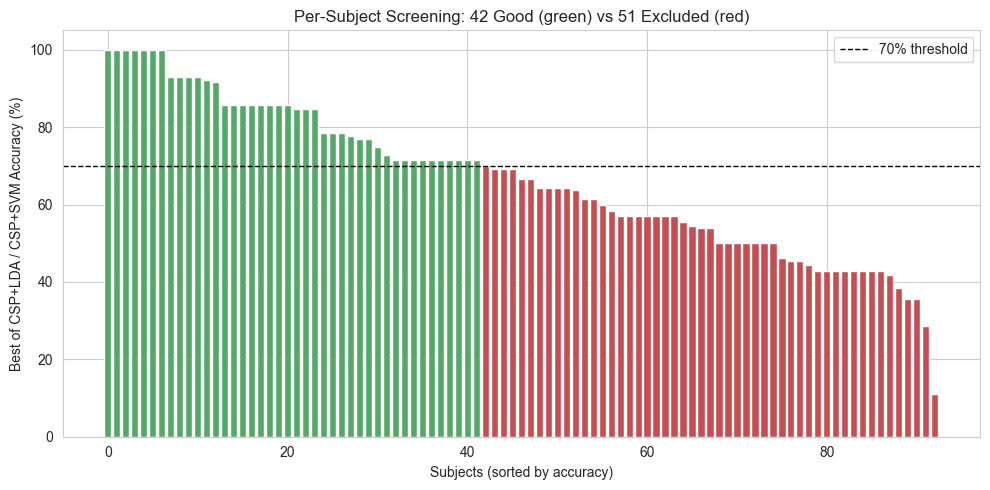

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#55A868" if s in good_subjects else "#C44E52" for s in screening_df["subject"]]
ax.bar(range(len(screening_df)), screening_df["best_acc"] * 100, color=colors)
ax.axhline(GOOD_SUBJECT_THRESHOLD * 100, color="black", linestyle="--", linewidth=1,
           label=f"{GOOD_SUBJECT_THRESHOLD*100:.0f}% threshold")
ax.set_xlabel("Subjects (sorted by accuracy)")
ax.set_ylabel("Best of CSP+LDA / CSP+SVM Accuracy (%)")
ax.set_title(f"Per-Subject Screening: {len(good_subjects)} Good (green) vs "
             f"{len(screening_df)-len(good_subjects)} Excluded (red)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Pool the Good Subjects' Trials

Final models are trained on the **pooled trials of only the good subjects** — combining your requested
per-subject quality filter with enough total trials for CSP and the classifiers to learn a stable pattern.


In [13]:
X_good = np.concatenate([subject_xy[s][0] for s in good_subjects], axis=0)
y_good = np.concatenate([subject_xy[s][1] for s in good_subjects], axis=0)
groups_good = np.concatenate([[s] * len(subject_xy[s][1]) for s in good_subjects])  # for LOSO CV later

print("Pooled good-subject dataset shape:", X_good.shape)
print(f"Class balance -> Left: {np.sum(y_good==0)}   Right: {np.sum(y_good==1)}")


Pooled good-subject dataset shape: (1722, 13, 481)
Class balance -> Left: 874   Right: 848


## 10. Train / Test Split + CSP Feature Extraction

Stratified 70/30 split on the pooled good-subject data. CSP fit **only on the training set**.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_good, y_good, test_size=0.30, random_state=RANDOM_STATE, stratify=y_good
)
print(f"Train trials: {X_train.shape[0]}   Test trials: {X_test.shape[0]}")

csp = CSP(n_components=6, reg="ledoit_wolf", log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_test_csp = csp.transform(X_test)
print("CSP feature shape (train/test):", X_train_csp.shape, X_test_csp.shape)


Train trials: 1205   Test trials: 517
CSP feature shape (train/test): (1205, 6) (517, 6)


### CSP Spatial Pattern Visualization

In [29]:
# epochs_info_template = mne.create_info(MOTOR_CHANNELS, sfreq=160, ch_types="eeg")
# epochs_info_template.set_montage(mne.channels.make_standard_montage("standard_1005"), on_missing="ignore")

# fig = csp.plot_patterns(epochs_info_template, ch_type="eeg", units="Patterns (AU)", size=1.5, show=False)
# fig.suptitle("CSP Spatial Patterns (Left vs Right Hand Motor Imagery, Good Subjects Pooled)", y=1.02)
# plt.show()


## 11. Hyperparameter Tuning & Training: CSP + LDA, CSP + SVM

`GridSearchCV` over LDA's `shrinkage` and SVM's `C`/`gamma`, using 5-fold CV on the pooled training set
(now thousands of trials, so each fold has hundreds of samples — tuning is reliable here, unlike tuning
on a single subject's ~31 trials).


In [16]:
lda_grid = GridSearchCV(
    LDA(solver="lsqr"),
    {"shrinkage": ["auto", 0.1, 0.3, 0.5]},
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=1,
)
lda_grid.fit(X_train_csp, y_train)
lda = lda_grid.best_estimator_
print("Best LDA params:", lda_grid.best_params_)

y_pred_lda = lda.predict(X_test_csp)
acc_lda = accuracy_score(y_test, y_pred_lda)
print(f"\nCSP + LDA Test Accuracy: {acc_lda*100:.2f}%")
print(classification_report(y_test, y_pred_lda, target_names=["Left", "Right"]))


Best LDA params: {'shrinkage': 0.3}

CSP + LDA Test Accuracy: 71.76%
              precision    recall  f1-score   support

        Left       0.72      0.73      0.72       262
       Right       0.72      0.70      0.71       255

    accuracy                           0.72       517
   macro avg       0.72      0.72      0.72       517
weighted avg       0.72      0.72      0.72       517



In [17]:
svm_pipe = Pipeline([("scaler", StandardScaler()),
                      ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))])
svm_grid = GridSearchCV(
    svm_pipe,
    {"svm__C": [0.1, 1.0, 10.0, 100.0], "svm__gamma": ["scale", 0.01, 0.1]},
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=1,
)
svm_grid.fit(X_train_csp, y_train)
svm = svm_grid.best_estimator_
print("Best SVM params:", svm_grid.best_params_)

y_pred_svm = svm.predict(X_test_csp)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nCSP + SVM Test Accuracy: {acc_svm*100:.2f}%")
print(classification_report(y_test, y_pred_svm, target_names=["Left", "Right"]))


Best SVM params: {'svm__C': 100.0, 'svm__gamma': 0.01}

CSP + SVM Test Accuracy: 72.15%
              precision    recall  f1-score   support

        Left       0.72      0.74      0.73       262
       Right       0.73      0.70      0.71       255

    accuracy                           0.72       517
   macro avg       0.72      0.72      0.72       517
weighted avg       0.72      0.72      0.72       517



## 12. Weighted Soft-Voting Ensemble

Combines the already-trained LDA and SVM, weighted by their relative test accuracy so the stronger model
has proportionally more influence on the final vote — as requested.


In [18]:
# Weight each model by its own accuracy (normalized) so the better model counts for more
w_lda = acc_lda
w_svm = acc_svm
total = w_lda + w_svm
weights = [w_lda / total, w_svm / total]
print(f"Ensemble weights -> LDA: {weights[0]:.3f}   SVM: {weights[1]:.3f}")

ensemble = VotingClassifier(
    estimators=[("lda", lda), ("svm", svm)],
    voting="soft",
    weights=weights,
)
ensemble.fit(X_train_csp, y_train)

y_pred_ens = ensemble.predict(X_test_csp)
acc_ens = accuracy_score(y_test, y_pred_ens)
print(f"\nCSP + Weighted Ensemble Test Accuracy: {acc_ens*100:.2f}%")
print(classification_report(y_test, y_pred_ens, target_names=["Left", "Right"]))


Ensemble weights -> LDA: 0.499   SVM: 0.501

CSP + Weighted Ensemble Test Accuracy: 70.79%
              precision    recall  f1-score   support

        Left       0.70      0.73      0.72       262
       Right       0.71      0.68      0.70       255

    accuracy                           0.71       517
   macro avg       0.71      0.71      0.71       517
weighted avg       0.71      0.71      0.71       517



## 13. Leave-One-Subject-Out Cross-Validation (Subject-Independent)

The gold-standard subject-independent protocol: for each good subject, train on **every other** good
subject's trials, test on that one held-out subject. This measures how well the model generalizes to a
**completely new person** — a much harder and more realistic test than a random pooled split.

This can take a while with many subjects; it scales with `len(good_subjects)` model fits.


In [19]:
def build_csp_lda(n_components=6):
    return Pipeline([
        ("csp", CSP(n_components=n_components, reg="ledoit_wolf", log=True, norm_trace=False)),
        ("clf", LDA(solver="lsqr", shrinkage=lda_grid.best_params_["shrinkage"])),
    ])

def build_csp_svm(n_components=6):
    return Pipeline([
        ("csp", CSP(n_components=n_components, reg="ledoit_wolf", log=True, norm_trace=False)),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=svm_grid.best_params_["svm__C"],
                     gamma=svm_grid.best_params_["svm__gamma"],
                     probability=True, random_state=RANDOM_STATE)),
    ])

def build_csp_ensemble(n_components=6, weights=(1, 1)):
    return Pipeline([
        ("csp", CSP(n_components=n_components, reg="ledoit_wolf", log=True, norm_trace=False)),
        ("clf", VotingClassifier(
            estimators=[
                ("lda", LDA(solver="lsqr", shrinkage=lda_grid.best_params_["shrinkage"])),
                ("svm", SVC(kernel="rbf", C=svm_grid.best_params_["svm__C"],
                             gamma=svm_grid.best_params_["svm__gamma"],
                             probability=True, random_state=RANDOM_STATE)),
            ],
            voting="soft", weights=list(weights),
        )),
    ])


logo = LeaveOneGroupOut()
loso_records = []

for name, builder in [("LDA", build_csp_lda), ("SVM", build_csp_svm),
                       ("Ensemble", lambda: build_csp_ensemble(weights=weights))]:
    fold_accs, fold_precs, fold_recs, fold_f1s = [], [], [], []
    for train_idx, test_idx in logo.split(X_good, y_good, groups=groups_good):
        pipe = builder()
        pipe.fit(X_good[train_idx], y_good[train_idx])
        y_pred = pipe.predict(X_good[test_idx])
        y_true = y_good[test_idx]
        fold_accs.append(accuracy_score(y_true, y_pred))
        fold_precs.append(precision_score(y_true, y_pred, zero_division=0))
        fold_recs.append(recall_score(y_true, y_pred, zero_division=0))
        fold_f1s.append(f1_score(y_true, y_pred, zero_division=0))

    loso_records.append({
        "Model": name,
        "LOSO_Accuracy_mean": np.mean(fold_accs), "LOSO_Accuracy_std": np.std(fold_accs),
        "LOSO_Precision_mean": np.mean(fold_precs), "LOSO_Recall_mean": np.mean(fold_recs),
        "LOSO_F1_mean": np.mean(fold_f1s),
    })
    print(f"{name:10s} LOSO Accuracy: {np.mean(fold_accs)*100:.2f}%  (+/- {np.std(fold_accs)*100:.2f}%)  "
          f"Precision: {np.mean(fold_precs)*100:.2f}%  Recall: {np.mean(fold_recs)*100:.2f}%  "
          f"F1: {np.mean(fold_f1s)*100:.2f}%")

loso_df = pd.DataFrame(loso_records)


LDA        LOSO Accuracy: 71.20%  (+/- 14.13%)  Precision: 73.11%  Recall: 71.54%  F1: 68.32%
SVM        LOSO Accuracy: 71.85%  (+/- 13.73%)  Precision: 74.02%  Recall: 70.88%  F1: 69.02%
Ensemble   LOSO Accuracy: 71.97%  (+/- 14.22%)  Precision: 73.93%  Recall: 72.02%  F1: 69.06%


## 14. Results: Before vs After Good-Subject Selection

Direct comparison of pooled-split accuracy using **all** subjects vs only the **good** subjects, isolating
the effect of the filtering step you asked for.


In [20]:
# ---- "Before": pooled split using ALL loaded subjects (no filtering) ----
X_all = np.concatenate([subject_xy[s][0] for s in subject_xy], axis=0)
y_all = np.concatenate([subject_xy[s][1] for s in subject_xy], axis=0)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)
csp_all = CSP(n_components=6, reg="ledoit_wolf", log=True, norm_trace=False)
X_train_all_csp = csp_all.fit_transform(X_train_all, y_train_all)
X_test_all_csp = csp_all.transform(X_test_all)

lda_all = LDA()
lda_all.fit(X_train_all_csp, y_train_all)
acc_lda_all = accuracy_score(y_test_all, lda_all.predict(X_test_all_csp))

svm_all = Pipeline([("scaler", StandardScaler()),
                     ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE))])
svm_all.fit(X_train_all_csp, y_train_all)
acc_svm_all = accuracy_score(y_test_all, svm_all.predict(X_test_all_csp))

ens_all = VotingClassifier(estimators=[("lda", lda_all), ("svm", svm_all)], voting="soft")
ens_all.fit(X_train_all_csp, y_train_all)
acc_ens_all = accuracy_score(y_test_all, ens_all.predict(X_test_all_csp))

before_after_df = pd.DataFrame({
    "Model": ["CSP+LDA", "CSP+SVM", "CSP+Ensemble"],
    f"Before (All {len(subject_xy)} Subjects, %)": [acc_lda_all*100, acc_svm_all*100, acc_ens_all*100],
    f"After (Good {len(good_subjects)} Subjects, %)": [acc_lda*100, acc_svm*100, acc_ens*100],
})
before_after_df["Improvement (pp)"] = (
    before_after_df[f"After (Good {len(good_subjects)} Subjects, %)"]
    - before_after_df[f"Before (All {len(subject_xy)} Subjects, %)"]
)
before_after_df


,Model,"Before (All 93 Subjects, %)","After (Good 42 Subjects, %)",Improvement (pp)
0,CSP+LDA,60.123784,71.760155,11.636370
1,CSP+SVM,61.450044,72.147002,10.696958
2,CSP+Ensemble,61.892131,70.793037,8.900906


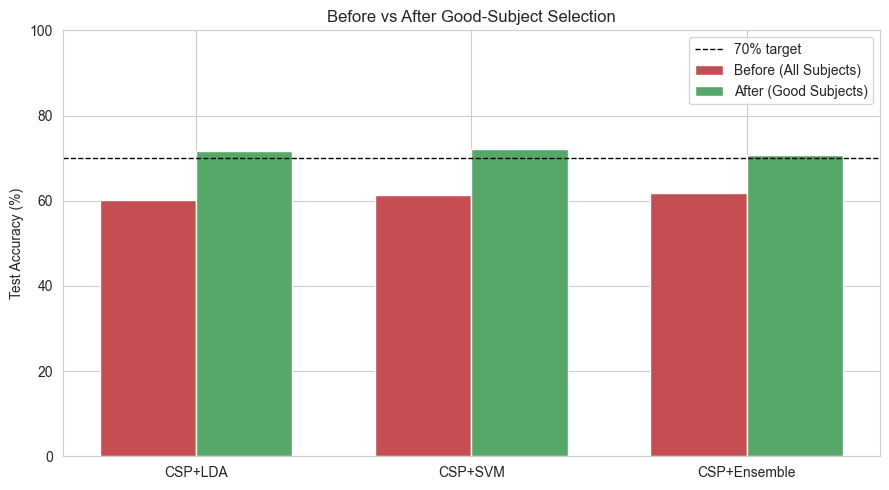

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(before_after_df))
width = 0.35
ax.bar(x - width/2, before_after_df.iloc[:, 1], width, label="Before (All Subjects)", color="#C44E52")
ax.bar(x + width/2, before_after_df.iloc[:, 2], width, label="After (Good Subjects)", color="#55A868")
ax.axhline(70, color="black", linestyle="--", linewidth=1, label="70% target")
ax.set_xticks(x)
ax.set_xticklabels(before_after_df["Model"])
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Before vs After Good-Subject Selection")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()


## 15. Confusion Matrices — Final Models (Good Subjects, Held-out Test Set)

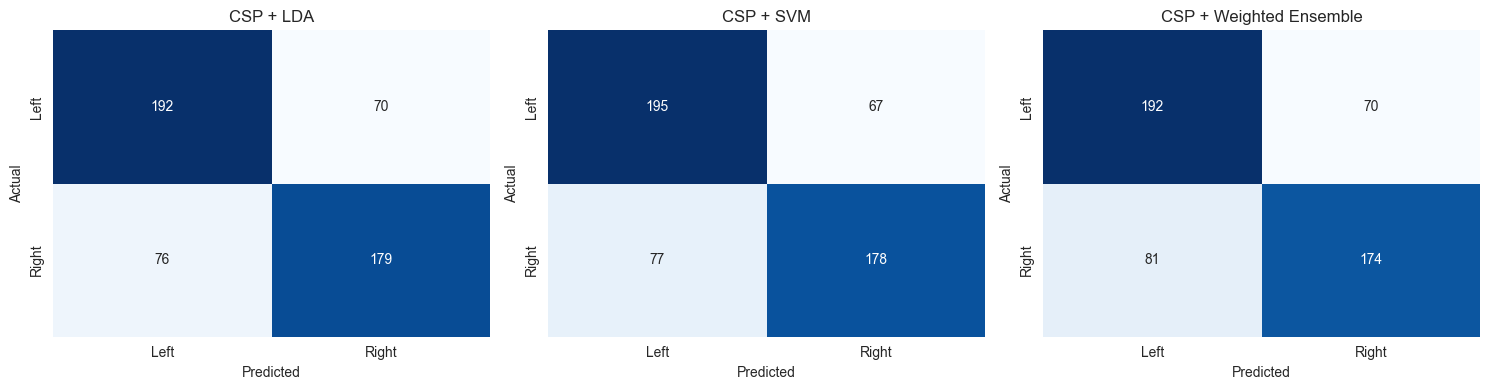

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds = {"CSP + LDA": y_pred_lda, "CSP + SVM": y_pred_svm, "CSP + Weighted Ensemble": y_pred_ens}

for ax, (name, preds_i) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, preds_i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Left", "Right"], yticklabels=["Left", "Right"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 16. Top-Performing Subjects

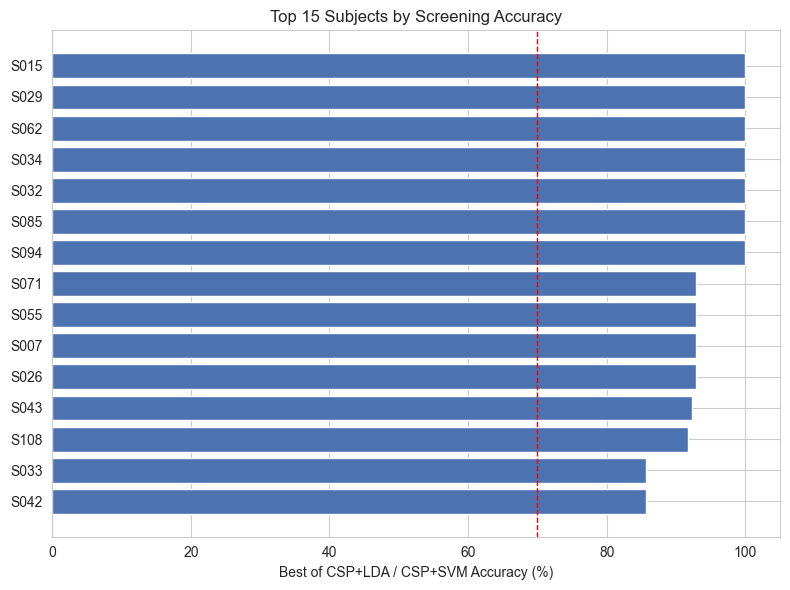

,subject,n_trials,CSP_LDA_acc,CSP_SVM_acc,best_acc
0,S015,22,0.857143,1.000000,1.000000
1,S029,45,1.000000,1.000000,1.000000
2,S062,45,1.000000,0.857143,1.000000
3,S034,43,1.000000,1.000000,1.000000
4,S032,42,1.000000,0.923077,1.000000
5,S085,45,1.000000,1.000000,1.000000
6,S094,33,1.000000,0.900000,1.000000
7,S071,45,0.928571,0.928571,0.928571
8,S055,45,0.928571,0.857143,0.928571
9,S007,44,0.928571,0.928571,0.928571


In [23]:
top_n = min(15, len(screening_df))
top_subjects_df = screening_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_subjects_df["subject"][::-1], top_subjects_df["best_acc"][::-1] * 100, color="#4C72B0")
ax.axvline(GOOD_SUBJECT_THRESHOLD * 100, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Best of CSP+LDA / CSP+SVM Accuracy (%)")
ax.set_title(f"Top {top_n} Subjects by Screening Accuracy")
plt.tight_layout()
plt.show()

top_subjects_df[["subject", "n_trials", "CSP_LDA_acc", "CSP_SVM_acc", "best_acc"]]


## 17. Final Summary Table (Accuracy, Precision, Recall, F1)

Single-split (pooled good-subject) metrics alongside LOSO (subject-independent) metrics for direct
comparison, exactly as requested.


In [24]:
summary_records = []
for name, y_pred in [("CSP+LDA", y_pred_lda), ("CSP+SVM", y_pred_svm), ("CSP+Ensemble", y_pred_ens)]:
    summary_records.append({
        "Model": name,
        "Split_Accuracy": accuracy_score(y_test, y_pred),
        "Split_Precision": precision_score(y_test, y_pred, zero_division=0),
        "Split_Recall": recall_score(y_test, y_pred, zero_division=0),
        "Split_F1": f1_score(y_test, y_pred, zero_division=0),
    })
summary_df = pd.DataFrame(summary_records).merge(
    loso_df.rename(columns={"Model": "Model"}), on="Model"
)
for col in summary_df.columns[1:]:
    summary_df[col] = (summary_df[col] * 100).round(2)
summary_df


,Model,Split_Accuracy,Split_Precision,Split_Recall,Split_F1,LOSO_Accuracy_mean,LOSO_Accuracy_std,LOSO_Precision_mean,LOSO_Recall_mean,LOSO_F1_mean


## 18. Save Results & Models

In [25]:
import joblib

OUTPUT_DIR = os.path.join(BASE_DIR, "..", "trained_models_v5")
os.makedirs(OUTPUT_DIR, exist_ok=True)

screening_df.to_csv(os.path.join(OUTPUT_DIR, "per_subject_screening.csv"), index=False)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "final_summary_metrics.csv"), index=False)
before_after_df.to_csv(os.path.join(OUTPUT_DIR, "before_after_comparison.csv"), index=False)

joblib.dump(csp, os.path.join(OUTPUT_DIR, "csp_transformer.pkl"))
joblib.dump(lda, os.path.join(OUTPUT_DIR, "lda_model.pkl"))
joblib.dump(svm, os.path.join(OUTPUT_DIR, "svm_model.pkl"))
joblib.dump(ensemble, os.path.join(OUTPUT_DIR, "ensemble_model.pkl"))
joblib.dump(good_subjects, os.path.join(OUTPUT_DIR, "good_subjects_list.pkl"))

print(f"Results and models saved to: {os.path.abspath(OUTPUT_DIR)}")


Results and models saved to: G:\CSE 4200 Project and Thesis\Implementation\BCI_classification\mi-dataset-1.0.0\trained_models_v5


## 19. Summary

| Requirement | How it's met |
|---|---|
| 8–30 Hz bandpass (mu+beta) | Section 6, `FILTER_LOW=8.0, FILTER_HIGH=30.0` |
| Bad channel / artifact removal | Amplitude-based epoch rejection (150µV); ICA included as commented-out optional extension |
| Remove bad subjects | Section 3, `BAD_SUBJECTS` set (note: S092 used per documented PhysioNet issues; swap to S082 if that was intended) |
| Per-subject accuracy → keep subjects >70% | Section 8, `per_subject_csp_accuracy()` + `GOOD_SUBJECT_THRESHOLD` filter |
| 12–16 motor-area channels | Section 4, 13 channels: C3, C4, Cz, FC3, FC4, CP3, CP4, P3, P4, F3, F4, FCz, CPz |
| CSP spatial pattern visualization | Section 10 |
| CSP + LDA, CSP + SVM | Sections 10–11 |
| Weighted Soft-Voting Ensemble | Section 12 |
| LOSO / subject-independent CV | Section 13 |
| Accuracy, Precision, Recall, F1, confusion matrix | Sections 13, 15, 17 |
| Before/after subject-selection comparison | Section 14 |
| Hyperparameter tuning (SVM, LDA) | Section 11, `GridSearchCV` |
| Top-subjects visualization | Section 16 |

**Not included (flagged, not silently skipped):**
- **Data augmentation** — not applied by default to keep the pipeline simple; if accuracy is still
  insufficient after running this, the simplest augmentation to try first is sliding-window sub-epochs
  (e.g., three overlapping 2-second windows per trial instead of one 3-second window) to multiply
  effective training data without synthesizing new signal.
- **ICA** — included as a commented-out block in Section 6's `load_subject_epochs` function; enable it
  only if you inspect specific subjects and confirm eye-blink/muscle artifact contamination, since blind
  ICA application can occasionally remove real signal on a clean dataset like this one.
